In [1]:
import numpy as np
from sim_library.constants import k_eff, dR, m, kb, omega_eg
from scipy.constants import hbar, pi
import matplotlib.pyplot as plt
from pathlib import Path
from sim_library.simulation import simulate_pulses_single_atom, simulate_pulses_single_atom_analyt, simulate_pulses_p_dist, simulate_alg_cooling, simulate_alg_cooling_custom
from sim_library.sequences import RR3_gate, PulseSequence, UpPulse, DownPulse, FreeEvolution, gen_MDFEup_seq, gen_MDFEdown_seq, RR3_adjMDFE_500kHz
from sim_library.plotting import plot_state_trajectories, plot_bloch, plot_hist, save_gif, plot_coolingcycles_22, fit_gaussian, fit_gaussian_custom, display_table_compare, plot_bloch_multi
from sim_library.data_io import load_p_dists

### G(pi/8)

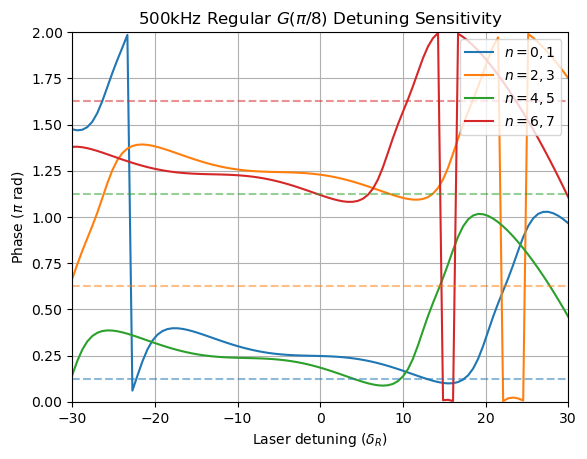

In [46]:

# Rabi frequency in 2*pi*Hz units
rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq # 2pi pulse time

# Set total resolution of time steps
n_steps = 1

indices = [8,10,12,14]

# Define basis: p in units of hbar*k (even p = ground state)
p_min = -8
p_max = 8
basis = np.arange(p_min, p_max + 1)


# Set doppler shift
atom_veloc = 0.0 # Stationary

detunings = np.linspace(-30*dR,+30*dR, 100)
phases = np.zeros((len(indices),len(detunings)))


for d, det in enumerate(detunings):
    # MDFE = gen_MDFEdown_seq(free_time=pi/(8*dR) - (0*0.039286*pi/(2*dR)), rabi_freq=rabi_freq*1e5, time_steps=n_steps, detuning=dR)
    # MDFE = gen_MDFEdown_seq(free_time=0.0054805*pi/dR, rabi_freq=rabi_freq, time_steps=n_steps, detuning=det)
    MDFE = gen_MDFEdown_seq(free_time=pi/(8*dR), rabi_freq=rabi_freq, time_steps=n_steps, detuning=det)

    for i in range(len(indices)):
        initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
        initial_state[indices[i]] = 1
        initial_state[indices[i]+1] = 1
        initial_state = initial_state/ np.linalg.norm(initial_state) # Normalise
        pulse_seq1 = PulseSequence()

        pulse1 = UpPulse(laser_det=np.full(n_steps,dR),phase=np.full(n_steps, pi/2), rabi_freq=np.full(n_steps,rabi_freq), duration=rabi_time/4)
        pulse2 = UpPulse(laser_det=np.full(n_steps,dR),phase=np.full(n_steps, pi/2), rabi_freq=np.full(n_steps,rabi_freq), duration=rabi_time/2)

        free = FreeEvolution(laser_det=(np.full(n_steps, -dR)), duration=(pi/(0.5*dR) - (1.8*0.039286*pi/(4*dR))))
        detuning = omega_eg/2
        free_time = 2*pi/(np.abs(dR-detuning))
        # free2 = FreeEvolution(laser_det=(np.full(n_steps, detuning)), duration=((9.83*free_time/16)))
        free2 = FreeEvolution(laser_det=(np.full(n_steps, detuning)), duration=((free_time/16)))
        
    

        pulse_seq1.add_pulses([MDFE])

        wave_func, times = simulate_pulses_single_atom_analyt(pulse_seq=pulse_seq1, basis=basis, initial_state=initial_state, d_shift=k_eff*atom_veloc)

        if i == 0:
            wave_funcs = np.zeros((len(indices),len(times),2), dtype=np.complex128)

        wave_funcs[i,:,:] = wave_func[:,indices[i]:indices[i]+2]


    angles = (np.angle(wave_funcs[:,:,1]) - np.angle(wave_funcs[:,:,0]))
    phases[:,d] = angles[:,-1]%(2*np.pi)/pi

### Raw Phase ###

fig, ax = plt.subplots()
ax.plot(detunings/dR,phases.transpose(), zorder=2)
ax.plot([-30,30],[0.125,0.125], ls='--', alpha=0.5, c='tab:blue')
ax.plot([-30,30],[0.625,0.625], ls='--', alpha=0.5, c='tab:orange')
ax.plot([-30,30],[1.125,1.125], ls='--', alpha=0.5, c='tab:green')
ax.plot([-30,30],[1.625,1.625], ls='--', alpha=0.5, c='tab:red')
ax.set_xlabel(r'Laser detuning ($\delta_R$)')
ax.set_ylabel(r'Phase ($\pi$ rad)')
# ax.set_ylabel(r'Phase / Target phase')
ax.set_title(r'500kHz Regular $G(\pi/8)$ Detuning Sensitivity')
ax.legend([r'$n=0,1$',r'$n=2,3$',r'$n=4,5$',r'$n=6,7$'], loc='upper right')


ax.set_ylim(0,2)
ax.set_xlim(detunings[0]/dR,detunings[-1]/dR)

ax.grid()

### Phase - Target Phase ###

# phases = phases.transpose()- [0.125,0.625,1.125,1.625]

# fig, ax = plt.subplots()
# ax.plot(detunings/dR,phases, zorder=2)
# ax.plot([-30,30],[0,0], ls='--', alpha=0.5, )
# ax.set_xlabel(r'Laser detuning ($\delta_R$)')
# # ax.set_ylabel(r'Phase ($\pi$ rad)')
# ax.set_ylabel(r'Phase - Target phase ($\pi$ rad)')
# ax.set_title(r'500kHz Regular $G(\pi/8)$ Detuning Sensitivity')
# ax.legend([r'$n=0,1$',r'$n=2,3$',r'$n=4,5$',r'$n=6,7$'], loc='upper right')

# ax.set_ylim(-1.5,1.5)
# ax.set_xlim(detunings[0]/dR,detunings[-1]/dR)

# ax.grid()





# display_table_compare(basis=basis, init_state=wave_func[0,:], final_state=wave_func[-1,:])
# plot_bloch(wave_func=wave_func[:,indices[0]:indices[1]+1], show=True)

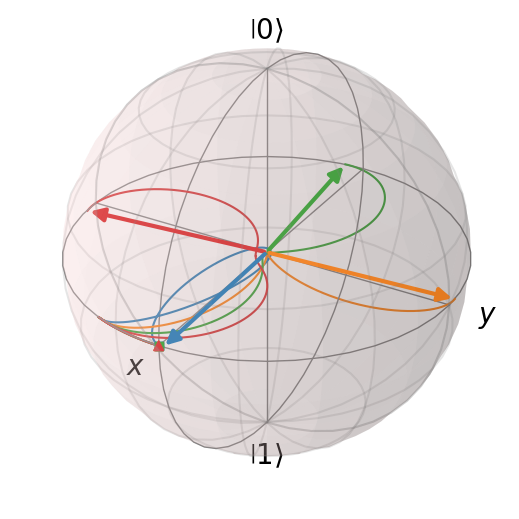

In [3]:
plot_bloch_multi(wave_func=wave_funcs, show=False)

### G(pi/4)

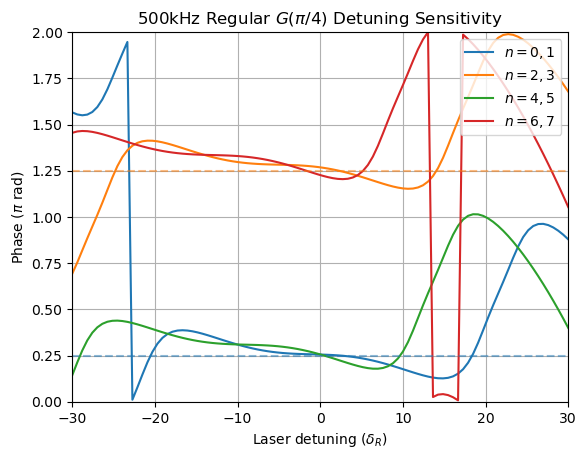

In [55]:

# Rabi frequency in 2*pi*Hz units
rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq # 2pi pulse time

# Set total resolution of time steps
n_steps = 1

indices = [8,10,12,14]

# Define basis: p in units of hbar*k (even p = ground state)
p_min = -8
p_max = 8
basis = np.arange(p_min, p_max + 1)


# Set doppler shift
atom_veloc = 0.0 # Stationary

detunings = np.linspace(-30*dR,+30*dR, 100)
phases = np.zeros((len(indices),len(detunings)))


for d, det in enumerate(detunings):
    # MDFE = gen_MDFEdown_seq(free_time=pi/(8*dR) - (0*0.039286*pi/(2*dR)), rabi_freq=rabi_freq*1e5, time_steps=n_steps, detuning=dR)
    MDFE = gen_MDFEdown_seq(free_time=0.13301*pi/dR, rabi_freq=rabi_freq, time_steps=n_steps, detuning=det)
    # MDFE = gen_MDFEdown_seq(free_time=pi/(4*dR), rabi_freq=rabi_freq, time_steps=n_steps, detuning=det)

    for i in range(len(indices)):
        initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
        initial_state[indices[i]] = 1
        initial_state[indices[i]+1] = 1
        initial_state = initial_state/ np.linalg.norm(initial_state) # Normalise
        pulse_seq1 = PulseSequence()

        
        detuning = omega_eg/2
        free_time = 2*pi/(np.abs(dR-detuning))
        # free2 = FreeEvolution(laser_det=(np.full(n_steps, detuning)), duration=((9.83*free_time/16)))
        free2 = FreeEvolution(laser_det=(np.full(n_steps, detuning)), duration=((free_time/16)))
        
    

        pulse_seq1.add_pulses([MDFE])

        wave_func, times = simulate_pulses_single_atom_analyt(pulse_seq=pulse_seq1, basis=basis, initial_state=initial_state, d_shift=k_eff*atom_veloc)

        if i == 0:
            wave_funcs = np.zeros((len(indices),len(times),2), dtype=np.complex128)

        wave_funcs[i,:,:] = wave_func[:,indices[i]:indices[i]+2]


    angles = (np.angle(wave_funcs[:,:,1]) - np.angle(wave_funcs[:,:,0]))
    phases[:,d] = angles[:,-1]%(2*np.pi)/pi

### Raw Phase ###

fig, ax = plt.subplots()
ax.plot(detunings/dR,phases.transpose(), zorder=2)
ax.plot([-30,30],[0.25,0.25], ls='--', alpha=0.5, c='tab:blue')
ax.plot([-30,30],[1.25,1.25], ls='--', alpha=0.5, c='tab:orange')

ax.set_xlabel(r'Laser detuning ($\delta_R$)')
ax.set_ylabel(r'Phase ($\pi$ rad)')
# ax.set_ylabel(r'Phase / Target phase')
ax.set_title(r'500kHz Regular $G(\pi/4)$ Detuning Sensitivity')
ax.legend([r'$n=0,1$',r'$n=2,3$',r'$n=4,5$',r'$n=6,7$'], loc='upper right')


ax.set_ylim(0,2)
ax.set_xlim(detunings[0]/dR,detunings[-1]/dR)

ax.grid()

### Phase - Target Phase ###

# phases = phases.transpose()- [0.25, 1.25, 0.25, 1.25]

# fig, ax = plt.subplots()
# ax.plot(detunings/dR,phases, zorder=2)
# ax.plot([-30,30],[0,0], ls='--', alpha=0.5, )
# ax.set_xlabel(r'Laser detuning ($\delta_R$)')
# # ax.set_ylabel(r'Phase ($\pi$ rad)')
# ax.set_ylabel(r'Phase - Target phase ($\pi$ rad)')
# ax.set_title(r'500kHz Regular $G(\pi/4)$ Detuning Sensitivity')
# ax.legend([r'$n=0,1$',r'$n=2,3$',r'$n=4,5$',r'$n=6,7$'], loc='upper right')

# ax.set_ylim(-1.5,1.5)
# ax.set_xlim(detunings[0]/dR,detunings[-1]/dR)

# ax.grid()





# display_table_compare(basis=basis, init_state=wave_func[0,:], final_state=wave_func[-1,:])
# plot_bloch(wave_func=wave_func[:,indices[0]:indices[1]+1], show=True)